In [1]:
import pandas as pd
import numpy as np
import yaml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Đọc file cấu hình config.yaml
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

print("Đã load config thành công!")

# 2. Load dữ liệu từ đường dẫn trong config
# Lưu ý: File data.csv của UCI dùng dấu chấm phẩy (;) để phân cách các cột
data_path = f"../{config['data']['raw_path']}"
df = pd.read_csv(data_path, sep=';') 

print(f"Kích thước bộ dữ liệu ban đầu: {df.shape}")

# Kiểm tra missing values (Bộ dữ liệu này đã được xác nhận là 100% đầy đủ)
print(f"Số lượng missing values: {df.isnull().sum().sum()}")

# 3. Tách features (X) và target (y)
target_col = config['data']['target_col']
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Label Encoding cho biến mục tiêu (Target)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Lưu lại từ điển mapping để dùng cho Tầng LLM sau này (Ví dụ: 0: Dropout, 1: Enrolled, 2: Graduate)
target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Từ điển phân loại Target: {target_mapping}")

# 5. Chia tập Train/Test TRƯỚC KHI áp dụng SMOTE (rất quan trọng để tránh Data Leakage)
# Sử dụng Stratify để giữ nguyên tỷ lệ phân phối nhãn
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=config['preprocessing']['test_size'], 
    random_state=config['preprocessing']['random_state'],
    stratify=y_encoded
)

print(f"Phân phối nhãn tập Train trước SMOTE: {Counter(y_train)}")

# 6. Áp dụng SMOTE để cân bằng dữ liệu trên tập Train
smote = SMOTE(random_state=config['preprocessing']['random_state'])
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Phân phối nhãn tập Train SAU KHI dùng SMOTE: {Counter(y_train_resampled)}")

# 7. Chuẩn hóa dữ liệu (Standard Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test) # Chỉ transform trên tập Test

# Chuyển lại thành DataFrame để dễ nhìn (Tùy chọn)
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Hoàn tất Data Layer! Dữ liệu đã sẵn sàng cho mô hình.")

Đã load config thành công!
Kích thước bộ dữ liệu ban đầu: (4424, 37)
Số lượng missing values: 0
Từ điển phân loại Target: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Phân phối nhãn tập Train trước SMOTE: Counter({np.int64(2): 1767, np.int64(0): 1137, np.int64(1): 635})
Phân phối nhãn tập Train SAU KHI dùng SMOTE: Counter({np.int64(2): 1767, np.int64(0): 1767, np.int64(1): 1767})
Hoàn tất Data Layer! Dữ liệu đã sẵn sàng cho mô hình.


Bắt đầu huấn luyện mô hình Phân loại (Giai đoạn 1)...
Đang huấn luyện Random Forest...
Đang huấn luyện XGBoost...

 KẾT QUẢ MÔ HÌNH RANDOM FOREST 
Accuracy: 0.7571
              precision    recall  f1-score   support

     Dropout       0.83      0.71      0.77       284
    Enrolled       0.48      0.55      0.51       159
    Graduate       0.83      0.86      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.77      0.76      0.76       885


 KẾT QUẢ MÔ HÌNH XGBOOST 
Accuracy: 0.7627
              precision    recall  f1-score   support

     Dropout       0.83      0.71      0.76       284
    Enrolled       0.48      0.55      0.51       159
    Graduate       0.84      0.87      0.86       442

    accuracy                           0.76       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.76      0.77       885



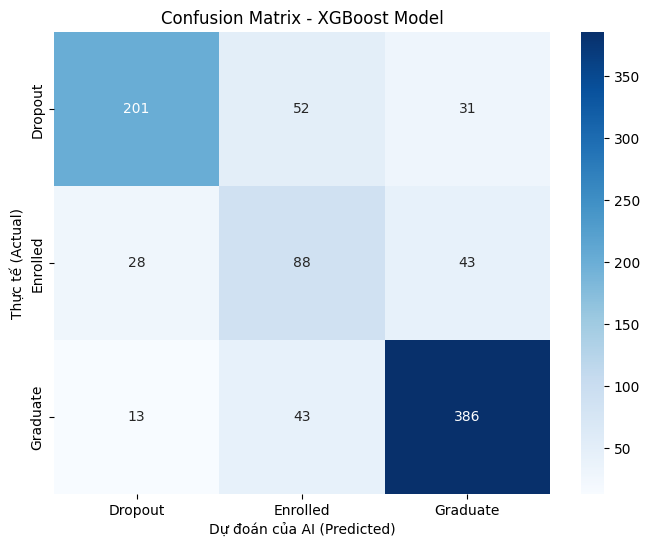

Hoàn tất Prediction Layer (Giai đoạn 1)!


In [4]:
# Import thư viện cho Tầng Prediction (Classification)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Bắt đầu huấn luyện mô hình Phân loại (Giai đoạn 1)...")

# 1. Khởi tạo mô hình Random Forest và XGBoost
# Sử dụng random_state để kết quả luôn cố định trong các lần chạy
rf_model = RandomForestClassifier(n_estimators=100, random_state=config['preprocessing']['random_state'])
xgb_model = xgb.XGBClassifier(n_estimators=config['model']['xgboost']['n_estimators'], 
                              max_depth=config['model']['xgboost']['max_depth'], 
                              learning_rate=config['model']['xgboost']['learning_rate'], 
                              random_state=config['preprocessing']['random_state'])

# 2. Huấn luyện mô hình trên tập dữ liệu ĐÃ ĐƯỢC SMOTE VÀ SCALE
print("Đang huấn luyện Random Forest...")
rf_model.fit(X_train_final, y_train_resampled)

print("Đang huấn luyện XGBoost...")
xgb_model.fit(X_train_final, y_train_resampled)

# 3. Dự đoán trên tập Test (Dữ liệu thực tế bị giấu đi, AI chưa từng thấy)
y_pred_rf = rf_model.predict(X_test_final)
y_pred_xgb = xgb_model.predict(X_test_final)

# 4. Đánh giá mô hình
target_names = ['Dropout', 'Enrolled', 'Graduate']

print("\n" + "="*40)
print(" KẾT QUẢ MÔ HÌNH RANDOM FOREST ")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

print("\n" + "="*40)
print(" KẾT QUẢ MÔ HÌNH XGBOOST ")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

# 5. Vẽ Confusion Matrix (Ma trận nhầm lẫn) cho XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán của AI (Predicted)')
plt.title('Confusion Matrix - XGBoost Model')
plt.show()

print("Hoàn tất Prediction Layer (Giai đoạn 1)!")

Bắt đầu Tầng 3: Giải thích mô hình với XAI (SHAP & LIME)...

Đang tính toán SHAP values (Quá trình này có thể mất 1-2 phút)...


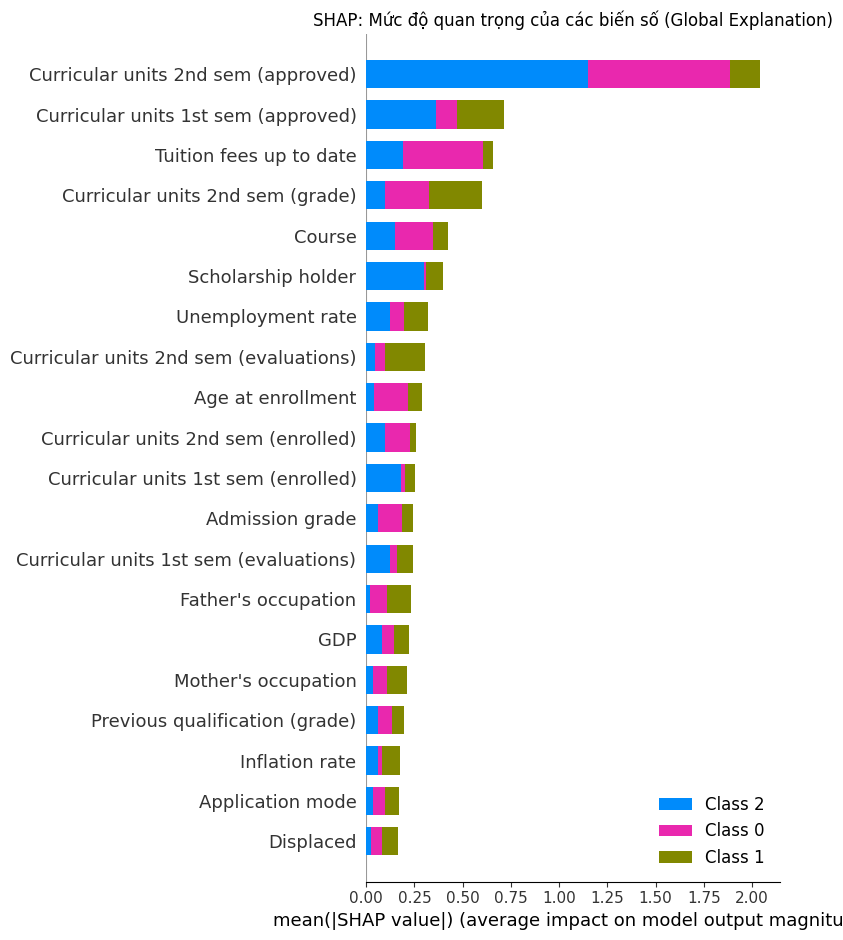


[LIME] Phân tích nguyên nhân rớt môn cho sinh viên tại index: [2, 12, 13, 17, 18, 19, 21, 22, 26, 29, 31, 34, 35, 38, 40, 41, 52, 53, 55, 56, 57, 59, 72, 74, 84, 95, 100, 106, 108, 112, 113, 114, 122, 130, 131, 135, 139, 140, 151, 152, 154, 155, 156, 158, 161, 167, 169, 171, 172, 175, 178, 179, 180, 186, 193, 196, 201, 212, 218, 223, 225, 230, 234, 241, 246, 247, 248, 249, 251, 255, 256, 266, 272, 275, 277, 279, 280, 282, 283, 286, 288, 293, 308, 316, 318, 322, 325, 334, 335, 338, 341, 344, 348, 350, 358, 360, 362, 363, 365, 371, 374, 379, 383, 387, 388, 389, 402, 405, 410, 411, 412, 417, 427, 430, 432, 433, 435, 447, 451, 454, 455, 457, 458, 463, 467, 472, 474, 475, 478, 481, 482, 483, 489, 490, 496, 501, 508, 511, 513, 515, 516, 519, 521, 523, 524, 525, 533, 534, 535, 537, 543, 550, 556, 557, 560, 563, 565, 568, 578, 586, 590, 591, 592, 593, 599, 606, 615, 616, 625, 632, 635, 637, 638, 639, 644, 650, 653, 658, 660, 667, 668, 669, 672, 674, 683, 695, 697, 700, 703, 711, 712, 718, 728

TypeError: only integer scalar arrays can be converted to a scalar index

In [9]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

print("Bắt đầu Tầng 3: Giải thích mô hình với XAI (SHAP & LIME)...")

# ==========================================
# 1. SHAP - Đánh giá mức độ quan trọng tổng thể
# ==========================================
print("\nĐang tính toán SHAP values (Quá trình này có thể mất 1-2 phút)...")
# Khởi tạo TreeExplainer cho mô hình XGBoost
explainer_shap = shap.TreeExplainer(xgb_model)

# Tính SHAP values trên tập Test
shap_values = explainer_shap.shap_values(X_test_final)

# Vẽ biểu đồ mức độ quan trọng của các đặc trưng (Global Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_final, plot_type="bar", show=False)
plt.title("SHAP: Mức độ quan trọng của các biến số (Global Explanation)")
plt.tight_layout()
plt.show()

# ==========================================
# 2. LIME - Giải thích cục bộ cho 1 sinh viên cụ thể
# ==========================================
# Tìm danh sách các sinh viên bị hệ thống XGBoost dự đoán là Dropout (Nhãn 0)
dropout_indices = [i for i, pred in enumerate(y_pred_xgb) if pred == 0]

# ĐÃ SỬA LỖI: Thêm  để lấy số index của sinh viên đầu tiên
sample_idx = dropout_indices 

print(f"\n[LIME] Phân tích nguyên nhân rớt môn cho sinh viên tại index: {sample_idx}")
print(f"Nhãn thực tế: {target_names[y_test[sample_idx]]}")
print(f"Hệ thống dự đoán: {target_names[y_pred_xgb[sample_idx]]}")

# Khởi tạo LIME Explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_final.values,
    feature_names=X_train_final.columns.tolist(),
    class_names=target_names,
    mode='classification',
    random_state=config['preprocessing']['random_state']
)

# Giải thích quyết định của XGBoost cho sinh viên này
exp = explainer_lime.explain_instance(
    data_row=X_test_final.iloc[sample_idx].values,
    predict_fn=xgb_model.predict_proba,
    num_features=5 # Chỉ lấy ra 5 lý do quan trọng nhất
)

# Hiển thị kết quả LIME
exp.show_in_notebook(show_table=True)
print("\nHoàn tất XAI Layer! Dữ liệu đã sẵn sàng để đưa vào LLM.")